In [2]:
from matplotlib.lines import lineStyles 
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

#up_c_file = 'mc_us_2018_5131h.txt'
up_c_file_19 = 'mc_up_2019_3993h.txt'

#up_bc = pd.read_csv(up_c_file,sep='\t', header=2, index_col=False)
up_bc_19 = pd.read_csv(up_c_file_19,sep='\t', header=2, index_col=False)
gdrive = '/Users/christiandewey/Library/CloudStorage/GoogleDrive-christian.w.dewey@gmail.com/My Drive/manuscripts/2023_Dewey-Fendorf-etal_meanders/plots/'

          !h    x    y       z
0        0.0  0.0  0.0  0.8631
1        1.0  0.0  0.0  0.8631
2        2.0  0.0  0.0  0.8724
3        3.0  0.0  0.0  0.8868
4        4.0  0.0  0.0  0.8980
...      ...  ...  ...     ...
5127  5127.0  0.0  0.0  0.8251
5128  5128.0  0.0  0.0  0.8357
5129  5129.0  0.0  0.0  0.8439
5130  5130.0  0.0  0.0  0.8451
5131  5131.0  0.0  0.0  0.8468

[5132 rows x 4 columns]


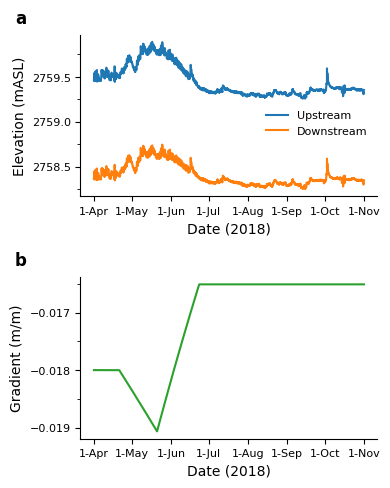

In [73]:
## removes dam from hydro

mc_len = 61 # m
starting_gradient = 0.018# m / m
base_elev = 2757.5 # mASL 

dn_18 = 'hydro_ds_2018_4-1_10-31-MZT.txt'
dn_bc = pd.read_csv(dn_18,sep='\t', header=2, index_col=False)
dn_bc['z'] =dn_bc['z']-0.6
up_elev = []

startdate = np.datetime64('2018-04-01')

gradient = starting_gradient
for z_dn, h in zip(dn_bc['z'], dn_bc['!h']):
    z_up = (gradient * mc_len) + z_dn
    up_elev.append(z_up)
    if (h > 480) and (h < 1200):
        f = 1+ 0.00008#- 0.00028
    elif (h >= 1200) and (h < 2000): 
        f = 1-.00018
    else:
        f = 1
    gradient = f *gradient 


xpltl = -0.2
ypltl = 1.1 


upstrm_bc = {'!h': up_bc['!h'], 'x': up_bc['x'], 'y': up_bc['y'], 'z': up_elev}
df = pd.DataFrame.from_dict(upstrm_bc)

bc_list = []
for i in range(len(df)):
    row_i = df.iloc[i,:]
    bc_list.append(f"{row_i['!h']:.3E}\t{row_i['x']:.3E}\t{row_i['y']:.3E}\t{row_i['z']:.3E}\n" )


if os.path.exists('mc_us_2018_5131h-NODAM.txt'):
        os.remove('mc_us_2018_5131h-NODAM.txt')
header_lines = ["TIME_UNITS h\n","DATA_UNITS m\n","!h	x	y	z\n"]
with open('mc_us_2018_5131h-NODAM.txt','a') as file:
     file.writelines(header_lines)
     file.writelines(bc_list)

dnstrm_bc = {'!h': dn_bc['!h'], 'x': dn_bc['x'], 'y': dn_bc['y'], 'z': dn_bc['z']}
df2 = pd.DataFrame.from_dict(dnstrm_bc)
print(df2)
bc_list = []
for i in range(len(df2)):
    row_i = df2.iloc[i,:]
    bc_list.append(f"{row_i['!h']:.3E}\t{row_i['x']:.3E}\t{row_i['y']:.3E}\t{row_i['z']:.3E}\n" )
if os.path.exists('mc_dn_2018_5131h-NODAM.txt'):
        os.remove('mc_dn_2018_5131h-NODAM.txt')
header_lines = ["TIME_UNITS h\n","DATA_UNITS m\n","!h	x	y	z\n"]
with open('mc_dn_2018_5131h-NODAM.txt','a') as file:
     file.writelines(header_lines)
     file.writelines(bc_list)


mpl.rcParams['mathtext.default'] = 'rm'
mpl.rcParams['legend.fontsize'] = 8
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8

times = [np.timedelta64(int(t),'h') for t in up_bc['!h']]
datex = [(startdate + dt) for dt in times]
timesx = datex 

fig, (ax, ax1) = plt.subplots(2, 1, figsize=(4,5))

ax.plot(timesx, np.array(up_elev)+base_elev, label = 'Upstream')
ax.plot(timesx, np.array(dn_bc['z'])+base_elev, label = 'Downstream')
ax.set_ylabel('Elevation (mASL)')
ax.set_xlabel('Date (2018)')

ax.legend(frameon = False, bbox_to_anchor=(1.0,0.45),loc='center right')

ax1.plot(timesx, (np.array(dn_bc['z'])-np.array(up_elev))/mc_len, color = 'C2')
ax1.set_ylabel('Gradient (m/m)')
ax1.set_xlabel('Date (2018)')

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
import matplotlib.ticker as tick
ax.yaxis.set_major_formatter(tick.FormatStrFormatter('%.1f'))

minor_locator = AutoMinorLocator(2)
ax.yaxis.set_minor_locator(minor_locator)
major_locator = MultipleLocator(0.5)
ax.yaxis.set_major_locator(major_locator)

minor_locator = AutoMinorLocator(2)
ax1.yaxis.set_minor_locator(minor_locator)
major_locator = MultipleLocator(0.001)
ax1.yaxis.set_major_locator(major_locator)

ax = ax 
ax.text(xpltl, ypltl,'a',
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes, fontweight='bold', fontsize = 12)


ax = ax1
ax.text(xpltl, ypltl,'b',
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes, fontweight='bold', fontsize = 12)


sns.despine()
fig.tight_layout()
plt.savefig(gdrive + 'mc_2018_bcs+gradient_240103.pdf', bbox_inches = 'tight')

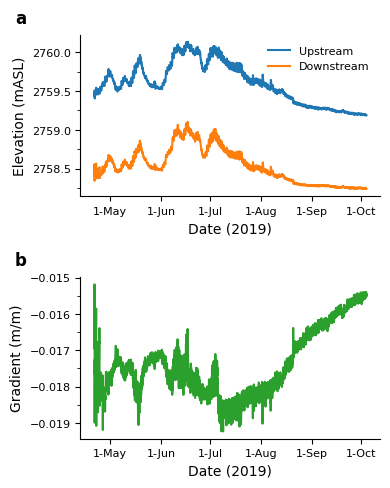

In [3]:
mc_len = 61 # m
base_elev = 2757.5 # mASL 
down_elev = []

mzt_dn_bc_19 = pd.read_csv('hydro_ds_2019_4-21_10-2-MZT.txt',sep='\t', header=2)
startdate = np.datetime64('2019-04-21')

for z_up, mzt_dn, h in zip(up_bc_19['z'], mzt_dn_bc_19['z'], up_bc_19['!h']):

    gradient = (mzt_dn - z_up-0.6) / 52.  # 52 m is length of mzt; m / m 

    mc_drop = gradient * mc_len # 61 m is length of mcp

    z_down = mc_drop + z_up
    down_elev.append(z_down)


xpltl = -0.2
ypltl = 1.1 


dwnstrm_bc = {'!h': up_bc_19['!h'], 'x': up_bc_19['x'], 'y': up_bc_19['y'], 'z': down_elev}
df = pd.DataFrame.from_dict(dwnstrm_bc)

bc_list = []
for i in range(len(df)):
    row_i = df.iloc[i,:]
    bc_list.append(f"{row_i['!h']:.3E}\t{row_i['x']:.3E}\t{row_i['y']:.3E}\t{row_i['z']:.3E}\n" )

if os.path.exists('mc_dn_2019_3993h.txt'):
        os.remove('mc_dn_2019_3993h.txt')

header_lines = ["TIME_UNITS h\n","DATA_UNITS m\n","!h	x	y	z\n"]
with open('mc_dn_2019_3993h.txt','a') as file:
     file.writelines(header_lines)
     file.writelines(bc_list)


mpl.rcParams['mathtext.default'] = 'rm'
mpl.rcParams['legend.fontsize'] = 8
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8

times = [np.timedelta64(int(t),'h') for t in up_bc_19['!h']]
datex = [(startdate + dt) for dt in times]
timesx = datex 

fig, (ax, ax1) = plt.subplots(2, 1, figsize=(4,5))

ax.plot(timesx, np.array(up_bc_19['z'])+base_elev, label = 'Upstream')
ax.plot(timesx, np.array(down_elev)+base_elev, label = 'Downstream')
ax.set_ylabel('Elevation (mASL)')
ax.set_xlabel('Date (2019)')

ax.legend(frameon = False, bbox_to_anchor=(1.0,0.85),loc='center right')

ax1.plot(timesx, (np.array(down_elev)-np.array(up_bc_19['z']))/mc_len, color = 'C2')
ax1.set_ylabel('Gradient (m/m)')
ax1.set_xlabel('Date (2019)')

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
import matplotlib.ticker as tick
ax.yaxis.set_major_formatter(tick.FormatStrFormatter('%.1f'))

minor_locator = AutoMinorLocator(2)
ax.yaxis.set_minor_locator(minor_locator)
major_locator = MultipleLocator(0.5)
ax.yaxis.set_major_locator(major_locator)

minor_locator = AutoMinorLocator(2)
ax1.yaxis.set_minor_locator(minor_locator)
major_locator = MultipleLocator(0.001)
ax1.yaxis.set_major_locator(major_locator)

ax = ax 
ax.text(xpltl, ypltl,'a',
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes, fontweight='bold', fontsize = 12)


ax = ax1
ax.text(xpltl, ypltl,'b',
        horizontalalignment='center',
        verticalalignment='center',
        transform = ax.transAxes, fontweight='bold', fontsize = 12)


sns.despine()
fig.tight_layout()
plt.savefig(gdrive + 'mc_2019_bcs+gradient_240102.pdf', bbox_inches = 'tight')